## IMPORTING THE REQUIRED LIBRARIES 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

## LOADING THE TRAINING DATASET

In [2]:
df = pd.read_csv("./titanic/train.csv")

## VERIFYING THE LOADED TRAINING DATASET 

### inspecting the column names 

In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### inspecting sample records

In [4]:
df.head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### inspecting total number of records and columns

In [5]:
print(len(df)) 
print(len(df.columns))

891
12


## UNDERSTANDING THE DATA STRUCTURE

### inspecting the datatypes of each column 

In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

### inspecting the target variable 

In [7]:
target = "Survived"
print ( target)

Survived


### identifying the numerical features 

In [8]:
numerical_features = df.select_dtypes(include=["int64","float64"]).columns.tolist()
if target in numerical_features :
    numerical_features.remove(target)
print(numerical_features)

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


### identifying the categorical features

In [9]:
cateogorical_features = df.select_dtypes(include="string").columns.tolist()
cateogorical_features

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

## EXPLORATORY DATA ANALYSIS OF TRAINING DATA 

### survival distribution 

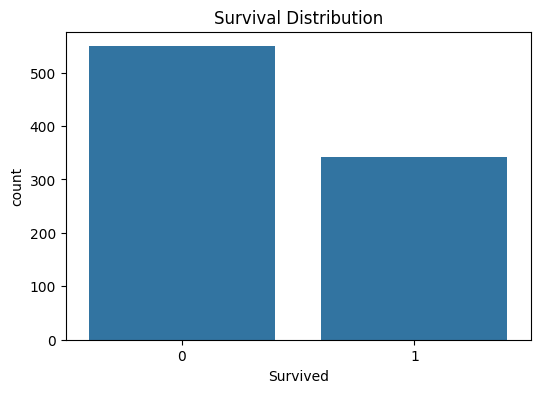

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df,x="Survived")
plt.title("Survival Distribution")
plt.show()

In [11]:
print("Survival counts :",df['Survived'].value_counts())

Survival counts : Survived
0    549
1    342
Name: count, dtype: int64


In [12]:
print("Survival percentage :",df['Survived'].value_counts(normalize=True)*100)

Survival percentage : Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


### feature wise survival analysis 

##### survival by cateogorical features 

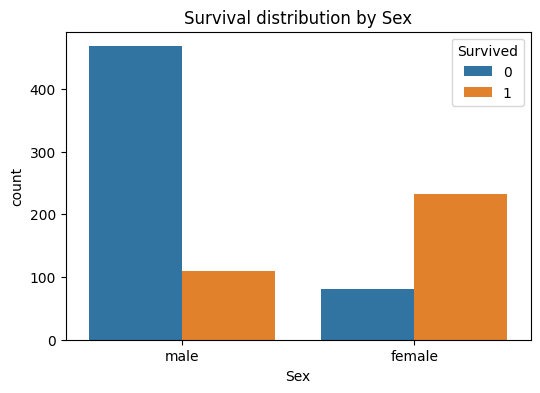

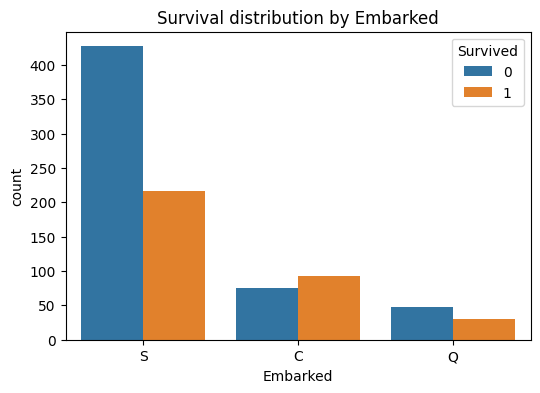

In [13]:
cateogorical_features_main =['Sex','Embarked']
for col in cateogorical_features_main :
    plt.figure(figsize=(6,4))
    sns.countplot(data= df ,x = col ,hue = 'Survived')
    plt.title(f"Survival distribution by {col}")
    plt.show()

#### survival by numerical features 

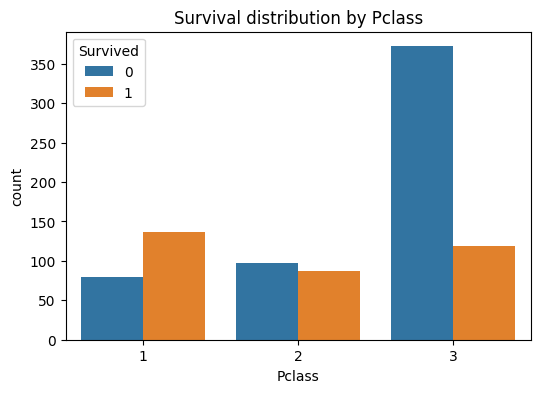

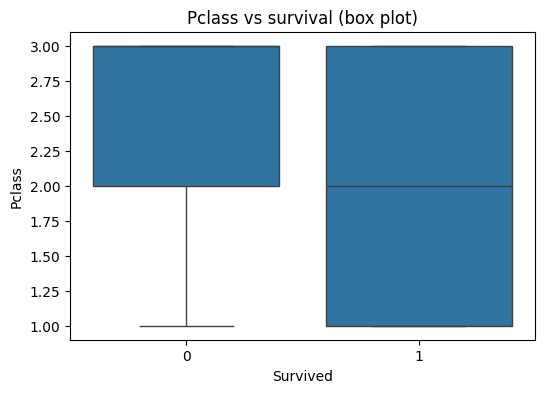

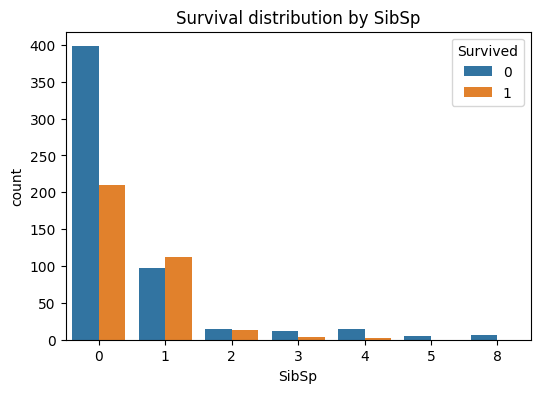

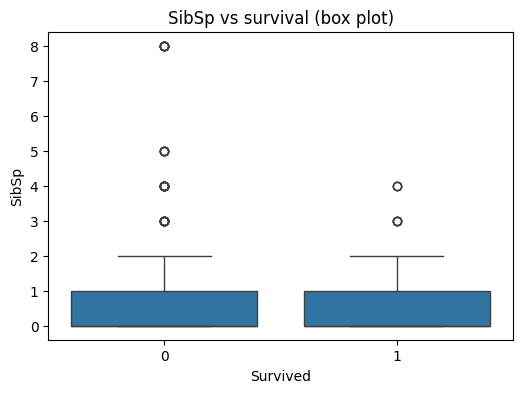

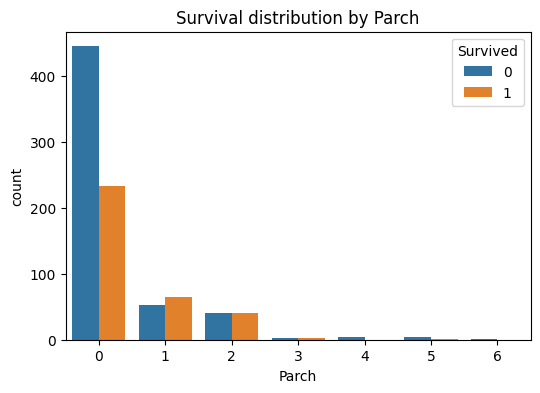

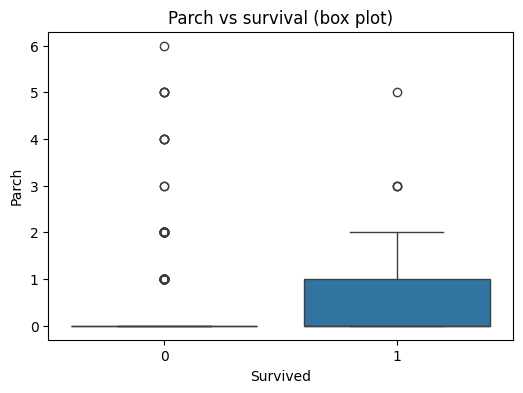

In [14]:
numerical_features_main = ['Pclass','SibSp','Parch']
for col in numerical_features_main :
    plt.figure(figsize=(6,4))
    sns.countplot(data = df , x =col,hue = 'Survived')
    plt.title(f"Survival distribution by {col}")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(data = df ,x='Survived',y=col)
    plt.title(f'{col} vs survival (box plot)')
    plt.show()

### Detecting outliers 

In [15]:
for col in numerical_features_main:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5) * iqr
    upper = q3 + (1.5) * iqr 
    outliers = df[(df[col]<lower) | (df[col]>upper)]
    print(f"{col} Outliers :\n",outliers[col])

Pclass Outliers :
 Series([], Name: Pclass, dtype: int64)
SibSp Outliers :
 7      3
16     4
24     3
27     3
50     4
59     5
63     3
68     4
71     5
85     3
88     3
119    4
159    8
164    4
171    4
176    3
180    8
182    4
201    8
229    3
233    4
261    4
266    4
278    4
324    8
341    3
374    3
386    5
409    3
480    5
485    3
541    4
542    4
634    3
642    3
683    5
686    4
726    3
787    4
792    8
813    4
819    3
824    4
846    8
850    4
863    8
Name: SibSp, dtype: int64
Parch Outliers :
 7      1
8      2
10     1
13     5
16     1
      ..
871    1
879    1
880    1
885    5
888    2
Name: Parch, Length: 213, dtype: int64


### skewness check

In [16]:
for col in numerical_features_main:
    skewness = df[col].skew()
    print(f"{col} Skewness :{skewness:.2f}")

Pclass Skewness :-0.63
SibSp Skewness :3.70
Parch Skewness :2.75


### Irrelevant features

#### correlation 

PassengerId   -0.005007
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64


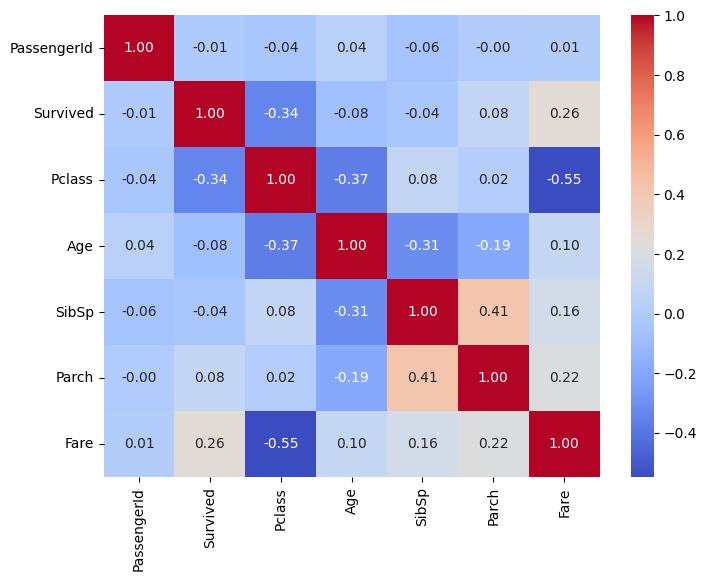

In [17]:
plt.figure(figsize=(8,6))
correlation =df.select_dtypes(include=["int64","float64"]).corr()
target_corr =correlation['Survived'].drop('Survived')

print(target_corr)
sns.heatmap(correlation, annot=True,cmap ='coolwarm',fmt='.2f')
plt.show()

In [18]:
# Temporary mapping for visualization only
df['Sex_encoded'] = df['Sex'].map({'female': 1, 'male': 0})
print(df[['Sex_encoded', 'Survived']].corr())

             Sex_encoded  Survived
Sex_encoded     1.000000  0.543351
Survived        0.543351  1.000000


#### dropping irrelevant numerical features

In [19]:
irrelevant_cols = ['PassengerId']
print("Dropping irrelevant columns :", irrelevant_cols)
df.drop(columns=irrelevant_cols,inplace=True,errors ='ignore')
df.head()

Dropping irrelevant columns : ['PassengerId']


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_encoded
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


#### dropping irrelevant cateogorical features 

In [20]:
print(df['Name'].nunique())
print(df['Ticket'].nunique())
print(df['Cabin'].nunique())

891
681
147


In [21]:
pd.crosstab(df['Sex'],df['Survived'],normalize='index')
#EDA using cross-tabulation shows that females had a significantly higher survival rate than males,
#indicating that the feature ‘Sex’ has strong predictive power and should be retained for modeling.”

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [22]:
#In the Titanic dataset, the Embarked feature represents the port of embarkation: C–Cherbourg, Q–Queenstown, and S–Southampton.
#The port of embarkation is not random:
'''
It is linked to ticket class
It correlates with socio-economic status
It indirectly affects survival probability
That's why Embarked is often a useful categorical feature
'''
pd.crosstab(df['Embarked'],df['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [23]:
irrelevant_cat_cols = ['Name', 'Ticket', 'Cabin']
df.drop(columns=irrelevant_cat_cols, inplace=True)


In [24]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_encoded
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


## DATA PREPROCESSING ON TRAINING DATA 

### handling missing values 

In [25]:
print("Missing values in each column ")
print(df.isnull().sum())

Missing values in each column 
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
Sex_encoded      0
dtype: int64


#### handling missing value in numerical colummn ( mean )

In [26]:
mean_value = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_value)

In [27]:
print(df.isnull().sum())

Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       2
Sex_encoded    0
dtype: int64


#### handling missing value in categorical column ( mode )

In [28]:
mode_value = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_value)

In [29]:
print(df.isnull().sum())

Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Sex_encoded    0
dtype: int64


### Removing irrelevant or redundant features 

In [30]:
'''
A feature should be kept only if it helps reduce uncertainty about the target (Survived).
Drop a column if:
It is an identifier
Example: PassengerId, Name, Ticket
These are unique labels, not patterns.
Model cannot generalize from them.
They add dimensionality without information.
It has no logical relationship with survival
Ask: “If I know this value, does it help me guess survival?”
If answer is no, drop it.
It duplicates information from another column
Example:
SibSp + Parch → both represent family size
You may combine them into FamilySize and drop originals.
It leaks no predictive signal
A column that looks numeric but behaves randomly w.r.t target.
'''
print()

### Encoding the categorical variables 

In [31]:

# 1. Drop original categorical column 'Sex' (already encoded)
df = df.drop(columns=['Sex'])

# 2. One-Hot Encode 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df[['Embarked_Q' ,'Embarked_S']] = df[['Embarked_Q' ,'Embarked_S']].astype(int)

In [32]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,1
3,1,1,35.0,1,0,53.1000,1,0,1
4,0,3,35.0,0,0,8.0500,0,0,1


### feature scaling 

In [33]:
#feature scaling is the process of bringing numerical features to similar scale so that no single feature dominates model due to its magnitude
'''Age → small range (≈ 0–80)
Fare → large range (≈ 0–512)
Without scaling, Fare will dominate distance calculations, which is incorrect.'''
 
# standardization ( Z -score scaling ) 
#X new = ( X - mean ) / variance 

scaling_features = ['Age','Fare']
scaler = StandardScaler()
df[scaling_features] = scaler.fit_transform(df[scaling_features])
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_Q,Embarked_S
0,0,3,-0.592481,1,0,-0.502445,0,0,1
1,1,1,0.638789,1,0,0.786845,1,0,0
2,1,3,-0.284663,0,0,-0.488854,1,0,1
3,1,1,0.407926,1,0,0.420730,1,0,1
4,0,3,0.407926,0,0,-0.486337,0,0,1


## FEATURE SELECTION AND DATA PREPARATION 

### final feature matrix 

In [34]:
selected_features = [
    'Pclass',
    'Age',
    'Fare',
    'Sex_encoded',
    'Embarked_Q',
    'Embarked_S'
]

X = df[selected_features]
Y = df['Survived']

In [35]:
X.head()

,Pclass,Age,Fare,Sex_encoded,Embarked_Q,Embarked_S
0,3,-0.592481,-0.502445,0,0,1
1,1,0.638789,0.786845,1,0,0
2,3,-0.284663,-0.488854,1,0,1
3,1,0.407926,0.420730,1,0,1
4,3,0.407926,-0.486337,0,0,1


In [36]:
Y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## MODEL BUILDING 

### ALGORITHMS :
1.**LOGISTIC REGRESSION** <br>
2.**DECISION TREE** <br>
3.**RANDOM FOREST** 

### split the train data into train and validation data

In [37]:
X_train , X_validate ,Y_train , Y_validate = train_test_split(X,Y,test_size= 0.2,random_state = 42,stratify = Y)

### train the model on train split using three algorithms 

In [38]:
lgr_model = LogisticRegression(max_iter=1000)
lgr_model.fit(X_train,Y_train)

dt_model = DecisionTreeClassifier(criterion='gini',max_depth=None,random_state=42)
dt_model.fit(X_train,Y_train)

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)

print()

### predict on validation data 

In [39]:
Y_validate_predict_lgr = lgr_model.predict(X_validate)
Y_validate_predict_dt = dt_model.predict(X_validate)
Y_validate_predict_rf = rf_model.predict(X_validate)


## EVALUATION METRICS ( USING VALIDATION DATA )

### accurcy 

In [40]:
accuracy = accuracy_score(Y_validate ,Y_validate_predict_lgr)
print ( f"{'VALIDATION ACCURACY USING LOGISTIC REGRESSION': <50}:{accuracy}")

accuracy = accuracy_score(Y_validate ,Y_validate_predict_dt)
print (f"{'VALIDATION ACCURACY USING DECISION TREE': <50}:{accuracy}")

accuracy = accuracy_score(Y_validate ,Y_validate_predict_rf)
print (f"{'VALIDATION ACCURACY USING RANDOM FOREST CLASSIFIER': <50}:{accuracy}")

VALIDATION ACCURACY USING LOGISTIC REGRESSION     :0.776536312849162
VALIDATION ACCURACY USING DECISION TREE           :0.7932960893854749
VALIDATION ACCURACY USING RANDOM FOREST CLASSIFIER:0.8100558659217877


### Confusion matrix

In [41]:
cm = confusion_matrix(Y_validate,Y_validate_predict_lgr)
print ('CONFUSION MATRIX USING LOGISTIC REGRESSION \n',cm)

cm = confusion_matrix(Y_validate,Y_validate_predict_dt)
print ('CONFUSION MATRIX USING DECISION TREES\n',cm)

cm = confusion_matrix(Y_validate,Y_validate_predict_rf)
print ('CONFUSION MATRIX USING RANDOM FOREST CLASSIFIER \n',cm)

CONFUSION MATRIX USING LOGISTIC REGRESSION 
 [[94 16]
 [24 45]]
CONFUSION MATRIX USING DECISION TREES
 [[93 17]
 [20 49]]
CONFUSION MATRIX USING RANDOM FOREST CLASSIFIER 
 [[96 14]
 [20 49]]


### Precision

In [42]:
precision = precision_score(Y_validate,Y_validate_predict_lgr)
print (f"{'PRECISION USING LOGISTIC REGRESSION': <50}:{precision}")

precision = precision_score(Y_validate,Y_validate_predict_dt)
print (f"{'PRECISION USING DECISION TREE': <50}:{precision}")

precision = precision_score(Y_validate,Y_validate_predict_rf)
print (f"{'PRECISION USING RANDOM FOREST CLASSIFIER': <50}:{precision}")

PRECISION USING LOGISTIC REGRESSION               :0.7377049180327869
PRECISION USING DECISION TREE                     :0.7424242424242424
PRECISION USING RANDOM FOREST CLASSIFIER          :0.7777777777777778


### Recall

In [43]:
recall = recall_score(Y_validate,Y_validate_predict_lgr)
print (f"{"RECALL USING LOGISTIC REGRESSION":<50}:{recall}")

recall = recall_score(Y_validate,Y_validate_predict_dt)
print (f"{"RECALL USING DECISION TREE": <50}:{recall}")

recall = recall_score(Y_validate,Y_validate_predict_rf)
print (f"{"RECALL USING RANDOM FOREST CLASSIFIER":<50}:{recall}")


RECALL USING LOGISTIC REGRESSION                  :0.6521739130434783
RECALL USING DECISION TREE                        :0.7101449275362319
RECALL USING RANDOM FOREST CLASSIFIER             :0.7101449275362319


### F1-Score

In [44]:
f1 = f1_score(Y_validate,Y_validate_predict_lgr)
print(f"{'F1 SCORE USING LOGISTIC REGRESSION':<50}:{f1}")

f1 = f1_score(Y_validate,Y_validate_predict_dt)
print(f"{'F1 SCORE USING DECISION TREE':<50}:{f1}")

f1 = f1_score(Y_validate,Y_validate_predict_rf)
print(f"{'F1 SCORE USING RANDOM FOREST CLASSIFIER':<50}:{f1}")

F1 SCORE USING LOGISTIC REGRESSION                :0.6923076923076923
F1 SCORE USING DECISION TREE                      :0.725925925925926
F1 SCORE USING RANDOM FOREST CLASSIFIER           :0.7424242424242424


### classification report

In [45]:
print('LOGISTIC REGRESSION :\n')
print (classification_report(Y_validate,Y_validate_predict_lgr))

print("\nDECISION TREE :\n")
print (classification_report(Y_validate,Y_validate_predict_dt))

print("\nRANDOM FOREST CLASSIFIER :")
print (classification_report(Y_validate,Y_validate_predict_rf))

LOGISTIC REGRESSION :

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179


DECISION TREE :

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.71      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


RANDOM FOREST CLASSIFIER :
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weigh

## CHOOSING BEST MODEL 

#### fitting random forest on full training data

In [ ]:
rf_model.fit(X,Y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## LOADING TEST DATASET

In [47]:
df_test = pd.read_csv("./titanic/test.csv")

## VERIFYING THE LOADED TEST DATASET

### inspecting the column names

In [48]:
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### inspecting total sample records 

In [49]:
    df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### inspecting total number of records and columns

In [50]:
print(len(df_test))
print(len(df_test.columns))

418
11


## DATA PREPROCESSING ON TEST DATA 

### handling the missing values 

In [51]:
print("Missing values in each column ")
print(df_test.isnull().sum())

Missing values in each column 
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


#### handling missing values in numerical column ( Mean and median )

In [52]:
df_test['Age']=df_test['Age'].fillna( mean_value)

In [53]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [54]:
median_value = df_test['Fare'].median()
df_test['Fare'] = df_test['Fare'].fillna(median_value)

In [55]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

### Removing the irrelevant or Redundant features 

In [56]:
irrelevant_cols_test = ['PassengerId','Name','Ticket','Cabin']
print("Dropping irrelevant columns :", irrelevant_cols_test)
df_test.drop(columns=irrelevant_cols_test,inplace=True,errors ='ignore')
df_test.head()

Dropping irrelevant columns : ['PassengerId', 'Name', 'Ticket', 'Cabin']


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


### Encoding the categorical variables

In [57]:
df_test['Sex_encoded'] = df_test['Sex'].map({'female': 1, 'male': 0})
df_test=df_test.drop(columns='Sex')

In [58]:
df_test = pd.get_dummies(df_test,columns=['Embarked'],drop_first=True)
df_test[['Embarked_Q','Embarked_S']] =df_test[['Embarked_Q','Embarked_S']].astype(int)
df_test.head() 

,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,0,1,0
1,3,47.0,1,0,7.0000,1,0,1
2,2,62.0,0,0,9.6875,0,1,0
3,3,27.0,0,0,8.6625,0,0,1
4,3,22.0,1,1,12.2875,1,0,1


### feature scaling

In [59]:
df_test[['Age', 'Fare']] = scaler.transform(df_test[['Age', 'Fare']])
df_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_Q,Embarked_S
0,3,0.369449,0,0,-0.490783,0,1,0
1,3,1.331378,1,0,-0.507479,1,0,1
2,2,2.485693,0,0,-0.453367,0,1,0
3,3,-0.207709,0,0,-0.474005,0,0,1
4,3,-0.592481,1,1,-0.401017,1,0,1


## FEATURE SELECTION 

In [60]:
selected_features = [
    'Pclass',
    'Age',
    'Fare',
    'Sex_encoded',
    'Embarked_Q',
    'Embarked_S'
]

X_test = df_test[selected_features]
X_test.head()

,Pclass,Age,Fare,Sex_encoded,Embarked_Q,Embarked_S
0,3,0.369449,-0.490783,0,1,0
1,3,1.331378,-0.507479,1,0,1
2,2,2.485693,-0.453367,0,1,0
3,3,-0.207709,-0.474005,0,0,1
4,3,-0.592481,-0.401017,1,0,1


#### sanity check

In [61]:
X.shape

(891, 6)

In [62]:
X_test.shape

(418, 6)

## PREDICTION

In [63]:
Y_test = rf_model.predict(X_test)

In [64]:
Y_test = pd.Series(Y_test)
Y_test.head()

0    0
1    0
2    0
3    1
4    0
dtype: int64

# TEST WITH CUSTOM INPUT 

In [68]:
def predict_survival_interactive(rf_model, selected_features):
    print("Enter passenger details to predict survival:")

    # Input prompts
    pclass = int(input("Pclass (1 = 1st, 2 = 2nd, 3 = 3rd): "))
    age = float(input("Age (in years): "))
    fare = float(input("Fare (ticket price): "))
    sex = input("Sex (male/female): ").strip().lower()
    embarked = input("Embarked (C/Q/S): ").strip().upper()

    # Encode features exactly matching dataset column names
    sex_encoded = 1 if sex == 'female' else 0
    embarked_Q = 1 if embarked == 'Q' else 0
    embarked_S = 1 if embarked == 'S' else 0

    # Create DataFrame with same column order as selected_features
    input_df = pd.DataFrame([[
        pclass,
        age,
        fare,
        sex_encoded,
        embarked_Q,
        embarked_S
    ]], columns=selected_features)

    # Make prediction
    prediction = rf_model.predict(input_df)[0]

    # Output result
    if prediction == 1:
        print("\nResult: Passenger is likely to SURVIVE")
    else:
        print("\nResult: Passenger is likely to NOT SURVIVE")
# Make sure rf_model is already trained on full training data
# selected_features = ['Pclass','Age','Fare','Sex_encoded','Embarked_Q','Embarked_S']

predict_survival_interactive(rf_model, selected_features)


Enter passenger details to predict survival:

Result: Passenger is likely to SURVIVE
